<a href="https://colab.research.google.com/github/salvadorGoros/miner-a-de-datos/blob/main/%C3%81rbol_de_decisi%C3%B3n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**EJERCICIO 1: NIVEL DE ESTRES**

--- CÁLCULOS TEÓRICOS ---
Entropía Total: 1.0000
Ganancia de Info (Sueño): 0.1887
Ganancia de Info (Ejercicio): 0.1887
Ganancia de Info (Carga_Tareas): 0.1887
-------------------------


/tmp/ipykernel_1286/687376362.py:45: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_num = df.replace(mapeos)


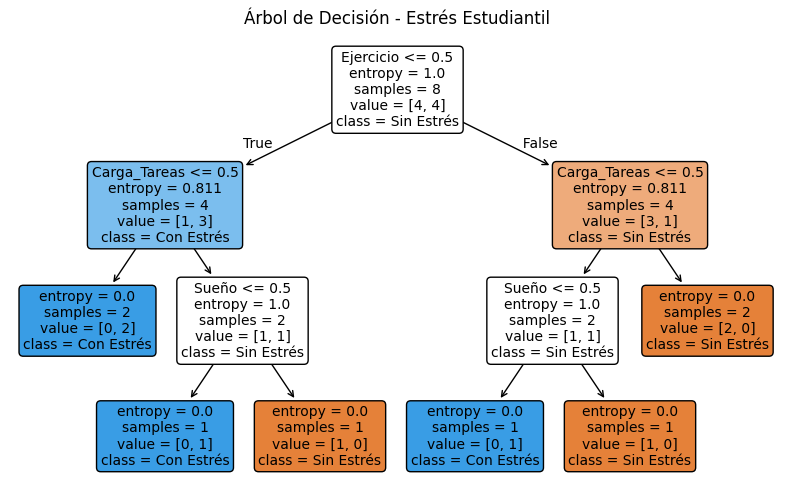


Predicción para [Sueño=Poco, Ejercicio=No, Carga=Alta] -> ¿Tiene estrés?: Sí


In [1]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# 1. Crear el Dataset
data = {
    'Sueño': ['Poco', 'Poco', 'Poco', 'Suficiente', 'Suficiente', 'Suficiente', 'Poco', 'Suficiente'],
    'Ejercicio': ['No', 'No', 'Sí', 'No', 'Sí', 'Sí', 'Sí', 'No'],
    'Carga_Tareas': ['Alta', 'Normal', 'Alta', 'Alta', 'Normal', 'Alta', 'Normal', 'Normal'],
    'Estrés': ['Sí', 'Sí', 'Sí', 'Sí', 'No', 'No', 'No', 'No']
}
df = pd.DataFrame(data)

# 2. Funciones para Entropía y Ganancia de Información
def calcular_entropia(columna_target):
    _, conteos = np.unique(columna_target, return_counts=True)
    probabilidades = conteos / conteos.sum()
    return -np.sum(probabilidades * np.log2(probabilidades))

def ganancia_informacion(df, atributo, target):
    entropia_total = calcular_entropia(df[target])
    valores, conteos = np.unique(df[atributo], return_counts=True)

    entropia_ponderada = sum(
        (conteos[i] / sum(conteos)) * calcular_entropia(df[df[atributo] == valores[i]][target])
        for i in range(len(valores))
    )
    return entropia_total - entropia_ponderada

print("--- CÁLCULOS TEÓRICOS ---")
print(f"Entropía Total: {calcular_entropia(df['Estrés']):.4f}")
for col in ['Sueño', 'Ejercicio', 'Carga_Tareas']:
    print(f"Ganancia de Info ({col}): {ganancia_informacion(df, col, 'Estrés'):.4f}")
print("-" * 25)

# 3. Preparar datos para el modelo (Codificación)
# Scikit-Learn requiere valores numéricos
mapeos = {
    'Sueño': {'Poco': 0, 'Suficiente': 1},
    'Ejercicio': {'No': 0, 'Sí': 1},
    'Carga_Tareas': {'Alta': 0, 'Normal': 1},
    'Estrés': {'No': 0, 'Sí': 1}
}
df_num = df.replace(mapeos)

X = df_num[['Sueño', 'Ejercicio', 'Carga_Tareas']]
y = df_num['Estrés']

# 4. Entrenar el Árbol de Decisión (Criterio: Entropía)
# random_state=42 para que el árbol siempre dibuje la misma estructura al desempatar
clf = DecisionTreeClassifier(criterion='entropy', random_state=42)
clf.fit(X, y)

# 5. Visualizar el árbol
plt.figure(figsize=(10, 6))
plot_tree(clf,
          feature_names=X.columns,
          class_names=['Sin Estrés', 'Con Estrés'],
          filled=True,
          rounded=True)
plt.title("Árbol de Decisión - Estrés Estudiantil")
plt.show()

# 6. Realizar la predicción requerida
# [Sueño=Poco (0), Ejercicio=No (0), Carga_Tareas=Alta (0)]
nuevo_estudiante = pd.DataFrame([[0, 0, 0]], columns=['Sueño', 'Ejercicio', 'Carga_Tareas'])
prediccion_num = clf.predict(nuevo_estudiante)[0]
resultado = "Sí" if prediccion_num == 1 else "No"

print(f"\nPredicción para [Sueño=Poco, Ejercicio=No, Carga=Alta] -> ¿Tiene estrés?: {resultado}")

**EJERCICO 2: ¿EL PACIENTE TIENE DIABETES?**

--- CÁLCULOS TEÓRICOS ---
Entropía Total: 1.0000
Ganancia de Información (IMC): 0.2781
Ganancia de Información (Azucar_Sangre): 0.2781
Ganancia de Información (Actividad_Fisica): 0.1245
-------------------------


/tmp/ipykernel_1286/218494348.py:43: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_num = df.replace(mapeos)


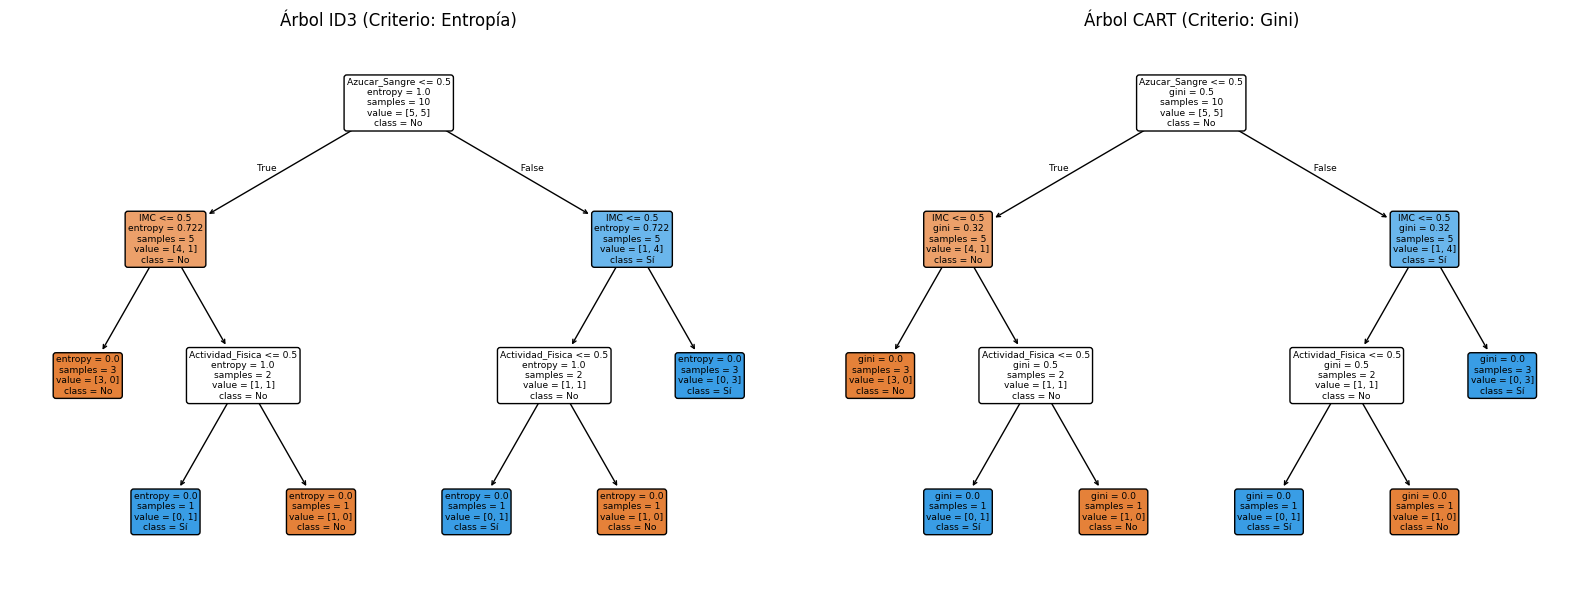


Predicción para [IMC=Alto, Azucar=Alta, Actividad=Poca] -> ¿Riesgo de Diabetes?: Sí


In [2]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# 1. Crear el Dataset
data = {
    'IMC': ['Alto', 'Alto', 'Alto', 'Normal', 'Normal', 'Normal', 'Alto', 'Normal', 'Normal', 'Alto'],
    'Azucar_Sangre': ['Alta', 'Alta', 'Normal', 'Alta', 'Normal', 'Normal', 'Normal', 'Alta', 'Normal', 'Alta'],
    'Actividad_Fisica': ['Poca', 'Mucha', 'Poca', 'Poca', 'Mucha', 'Poca', 'Mucha', 'Mucha', 'Poca', 'Poca'],
    'Diabetes': ['Sí', 'Sí', 'Sí', 'Sí', 'No', 'No', 'No', 'No', 'No', 'Sí']
}
df = pd.DataFrame(data)

# 2. Funciones para Cálculos Teóricos
def calcular_entropia(columna):
    _, conteos = np.unique(columna, return_counts=True)
    probs = conteos / conteos.sum()
    return -np.sum(probs * np.log2(probs))

def ganancia_informacion(df, atributo, target):
    entropia_total = calcular_entropia(df[target])
    valores, conteos = np.unique(df[atributo], return_counts=True)
    entropia_ponderada = sum(
        (conteos[i] / sum(conteos)) * calcular_entropia(df[df[atributo] == valores[i]][target])
        for i in range(len(valores))
    )
    return entropia_total - entropia_ponderada

print("--- CÁLCULOS TEÓRICOS ---")
print(f"Entropía Total: {calcular_entropia(df['Diabetes']):.4f}")
for col in ['IMC', 'Azucar_Sangre', 'Actividad_Fisica']:
    print(f"Ganancia de Información ({col}): {ganancia_informacion(df, col, 'Diabetes'):.4f}")
print("-" * 25)

# 3. Codificación de variables a numéricas
mapeos = {
    'IMC': {'Normal': 0, 'Alto': 1},
    'Azucar_Sangre': {'Normal': 0, 'Alta': 1},
    'Actividad_Fisica': {'Poca': 0, 'Mucha': 1},
    'Diabetes': {'No': 0, 'Sí': 1}
}
df_num = df.replace(mapeos)

X = df_num[['IMC', 'Azucar_Sangre', 'Actividad_Fisica']]
y = df_num['Diabetes']

# 4. Entrenar los modelos: ID3 (Entropía) vs CART (Gini)
clf_id3 = DecisionTreeClassifier(criterion='entropy', random_state=42)
clf_cart = DecisionTreeClassifier(criterion='gini', random_state=42)

clf_id3.fit(X, y)
clf_cart.fit(X, y)

# 5. Visualizar ambos árboles para comparar
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_tree(clf_id3, feature_names=X.columns, class_names=['No', 'Sí'], filled=True, rounded=True, ax=axes[0])
axes[0].set_title("Árbol ID3 (Criterio: Entropía)")

plot_tree(clf_cart, feature_names=X.columns, class_names=['No', 'Sí'], filled=True, rounded=True, ax=axes[1])
axes[1].set_title("Árbol CART (Criterio: Gini)")

plt.tight_layout()
plt.show()

# 6. Predicción requerida
# IMC=Alto (1), Azucar=Alta (1), Actividad=Poca (0)
nuevo_paciente = pd.DataFrame([[1, 1, 0]], columns=['IMC', 'Azucar_Sangre', 'Actividad_Fisica'])
prediccion_num = clf_id3.predict(nuevo_paciente)[0]
resultado = "Sí" if prediccion_num == 1 else "No"

print(f"\nPredicción para [IMC=Alto, Azucar=Alta, Actividad=Poca] -> ¿Riesgo de Diabetes?: {resultado}")